In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn

# Carregamento dos dados

In [3]:
df = pd.read_excel('/Users/pedro/Desktop/Tese/Dados/base_corrigida_30_04_25_lab.xlsx')

In [4]:
print("Dimensions of the dataset:", df.shape)
print(df.head())

Dimensions of the dataset: (1841, 48)
      ID  idade genero             TE  numerodeTE           TE_Loc  \
0    282     72      F    without RFT           0      without RFT   
1    911     70      F    without RFT           0      without RFT   
2   1386     50      F  1 or more RFT           2  posterior teeth   
3  19047     29      F    without RFT           0      without RFT   
4  21541     75      F    without RFT           0      without RFT   

           PA  numerodePA      PA_Loc TEcomPA  ... anticoagulantes  \
0  whitout AP           0  without AP      no  ...              no   
1  whitout AP           0  without AP      no  ...              no   
2  whitout AP           0  without AP      no  ...              no   
3  whitout AP           0  without AP      no  ...              no   
4  whitout AP           0  without AP      no  ...              no   

   antiarritmia  antidiabéticoOral  insulina  antiasmáticos  \
0            no                 no        no             

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1841 entries, 0 to 1840
Data columns (total 48 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   ID                                              1841 non-null   int64 
 1   idade                                           1841 non-null   int64 
 2   genero                                          1841 non-null   str   
 3   TE                                              1841 non-null   str   
 4   numerodeTE                                      1841 non-null   int64 
 5   TE_Loc                                          1841 non-null   str   
 6   PA                                              1841 non-null   str   
 7   numerodePA                                      1841 non-null   int64 
 8   PA_Loc                                          1841 non-null   str   
 9   TEcomPA                                         1841 non-null  

# Análise descritiva e exploratória

## Classificação e analise exploratória das variaveis

### Variaveis quantitativas

idade

numerodeTE

numerodePA

cargaendodontica

numerodecaries

numeroderaizesemboca

numerodedentespresentes

numerodedentesausentes

In [6]:
quant_vars = [
    "idade",
    "numerodeTE",
    "numerodePA",
    "cargaendodontica",
    "numerodecaries",
    "numeroderaizesemboca",
    "numerodedentespresentes",
    "numerodedentesausentes"
]

# Estatísticas descritivas para variáveis quantitativas
desc_stats = df[quant_vars].describe().T
desc_stats["median"] = df[quant_vars].median()
desc_stats["IQR"] = df[quant_vars].quantile(0.75) - df[quant_vars].quantile(0.25)

print("\n===== Estatísticas Descritivas =====\n")
print(desc_stats)




===== Estatísticas Descritivas =====

                          count       mean        std   min   25%   50%   75%  \
idade                    1841.0  43.833786  17.552640  18.0  28.0  43.0  58.0   
numerodeTE               1841.0   1.169473   1.793576   0.0   0.0   0.0   2.0   
numerodePA               1841.0   0.941336   1.314977   0.0   0.0   0.0   2.0   
cargaendodontica         1841.0   2.110266   2.592906   0.0   0.0   1.0   3.0   
numerodecaries           1841.0   5.391092   4.567752   0.0   2.0   5.0   8.0   
numeroderaizesemboca     1841.0   0.424226   2.025071   0.0   0.0   0.0   0.0   
numerodedentespresentes  1841.0  23.787615   5.122837   8.0  21.0  26.0  28.0   
numerodedentesausentes   1841.0   4.212385   5.122837   0.0   0.0   2.0   7.0   

                          max  median   IQR  
idade                    88.0    43.0  30.0  
numerodeTE               13.0     0.0   2.0  
numerodePA                9.0     0.0   2.0  
cargaendodontica         19.0     1.0   3.0  
n

In [7]:
# Teste de Normalidade (Shapiro-Wilk)
print("\n===== Teste de Normalidade (Shapiro-Wilk) =====\n")

normality_results = {}

for var in quant_vars:
    stat, p = stats.shapiro(df[var].dropna())
    normality_results[var] = {"Shapiro_stat": stat, "p_value": p}
    
    print(f"{var}: p-value = {p:.5f}")

normality_df = pd.DataFrame(normality_results).T


===== Teste de Normalidade (Shapiro-Wilk) =====

idade: p-value = 0.00000
numerodeTE: p-value = 0.00000
numerodePA: p-value = 0.00000
cargaendodontica: p-value = 0.00000
numerodecaries: p-value = 0.00000
numeroderaizesemboca: p-value = 0.00000
numerodedentespresentes: p-value = 0.00000
numerodedentesausentes: p-value = 0.00000


p < 0.001

Rejeitamos H₀

As variáveis não seguem distribuição normal, por isso só podemos usar testes não paramétricos

In [8]:
# Identificação de Outliers usando o método IQR
print("\n===== Outliers (Método IQR) =====\n")

for var in quant_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[var] < lower) | (df[var] > upper)]
    
    print(f"{var}: {len(outliers)} outliers")


===== Outliers (Método IQR) =====

idade: 0 outliers
numerodeTE: 68 outliers
numerodePA: 14 outliers
cargaendodontica: 89 outliers
numerodecaries: 33 outliers
numeroderaizesemboca: 292 outliers
numerodedentespresentes: 44 outliers
numerodedentesausentes: 44 outliers


### Boxplots

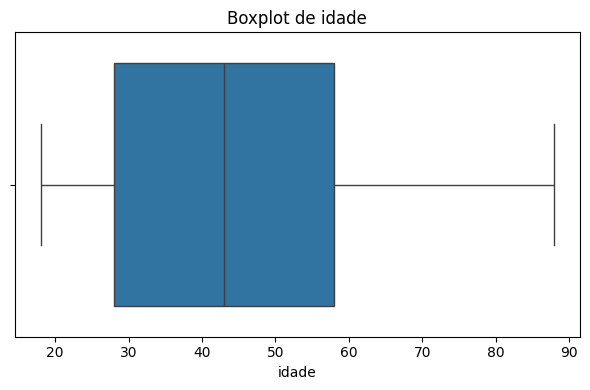

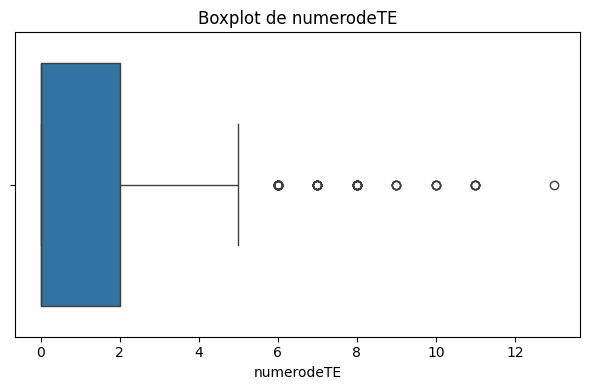

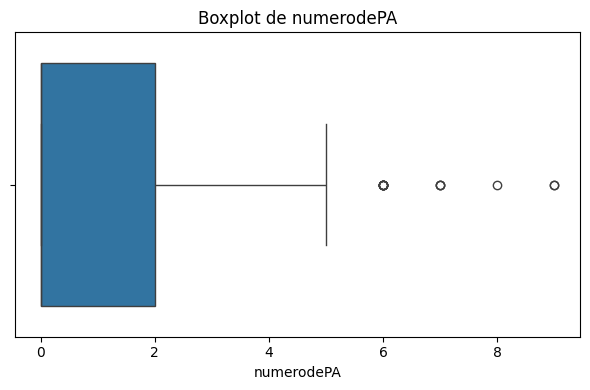

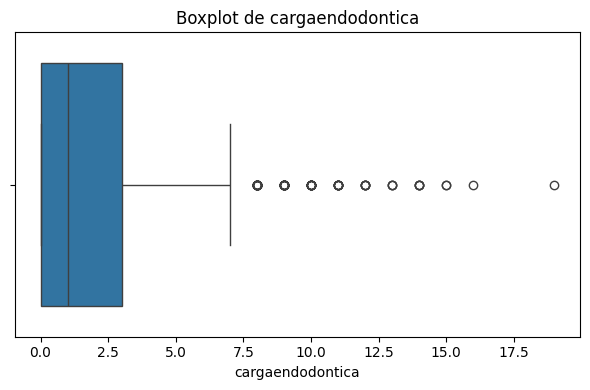

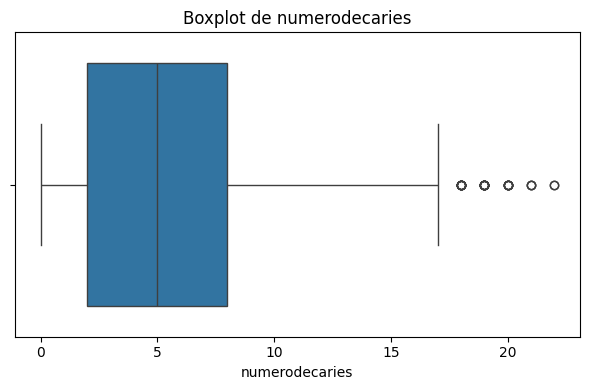

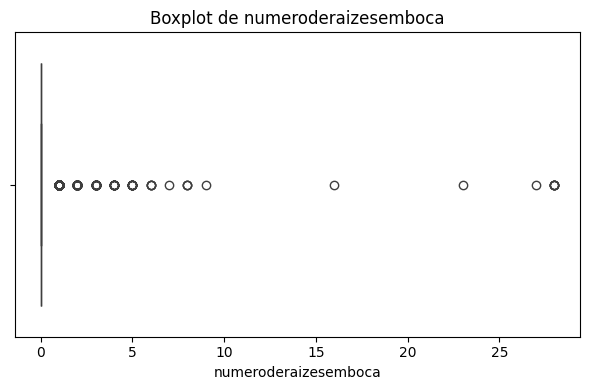

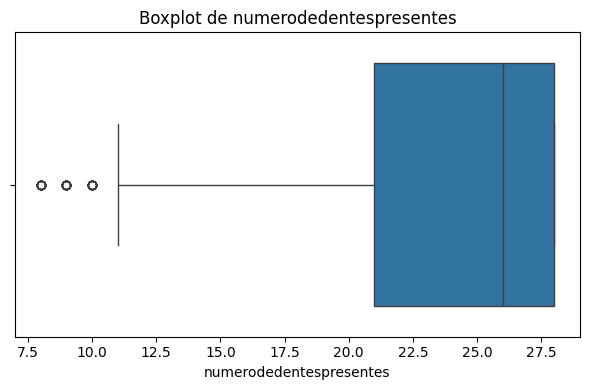

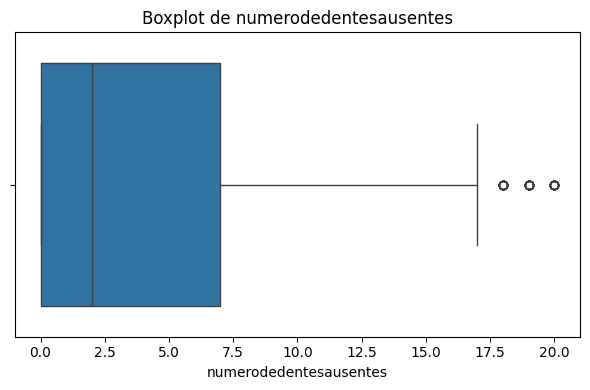

In [9]:
for var in quant_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot de {var}")
    plt.tight_layout()
    plt.show()

#### Histogramas com curva KDE

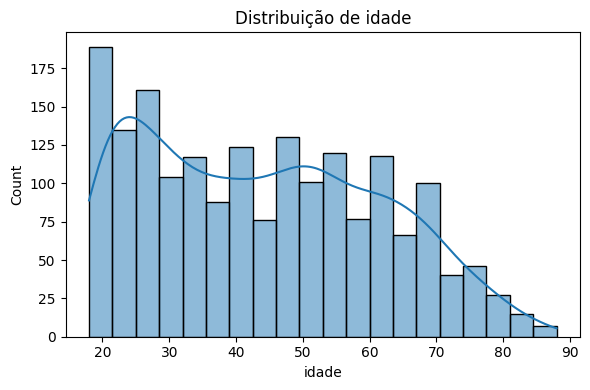

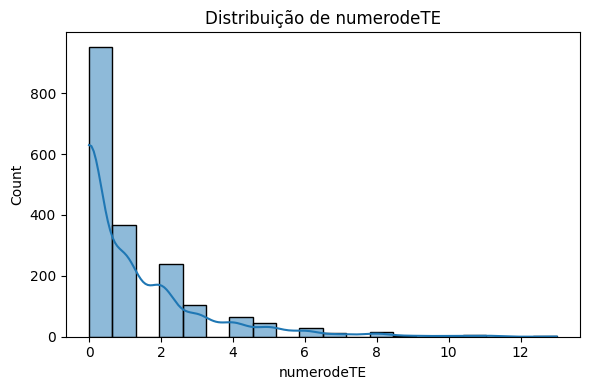

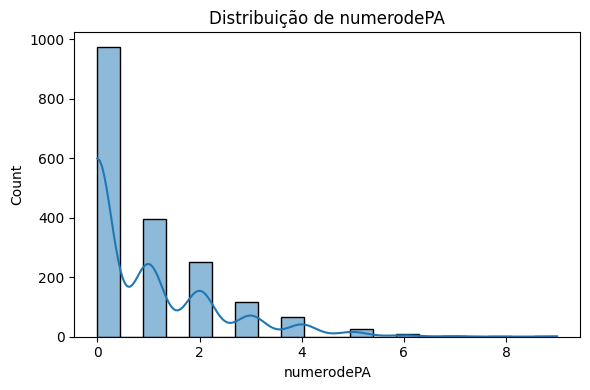

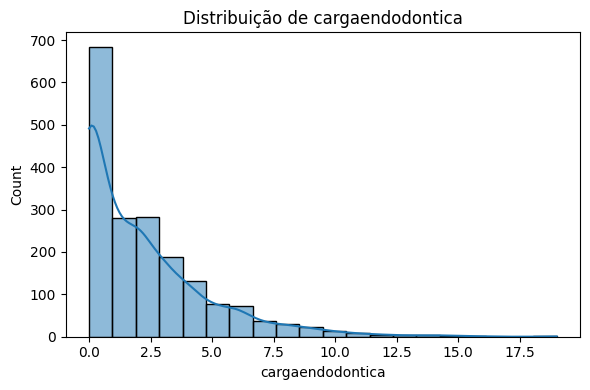

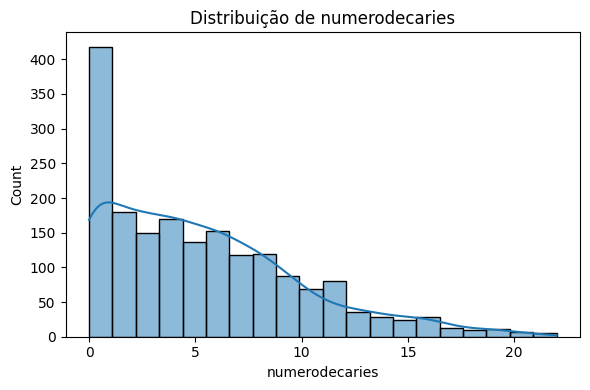

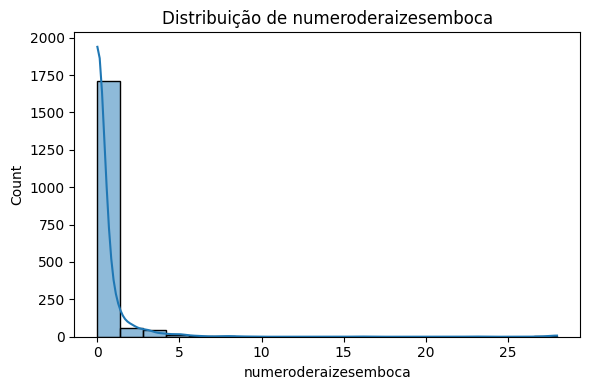

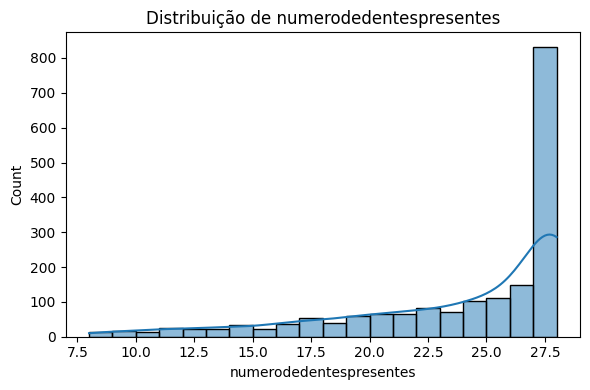

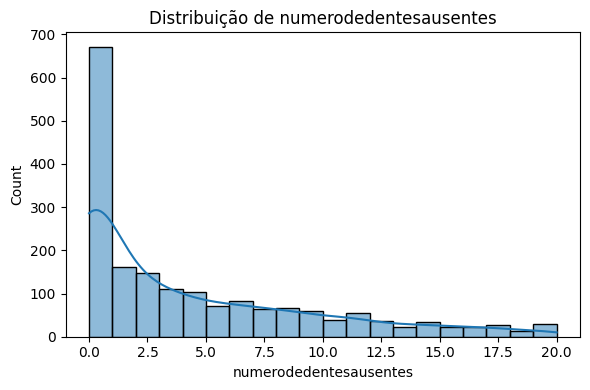

In [10]:
for var in quant_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[var], kde=True, bins=20)
    plt.title(f"Distribuição de {var}")
    plt.tight_layout()
    plt.show()


#### Q-Q Plots

<Figure size 500x500 with 0 Axes>

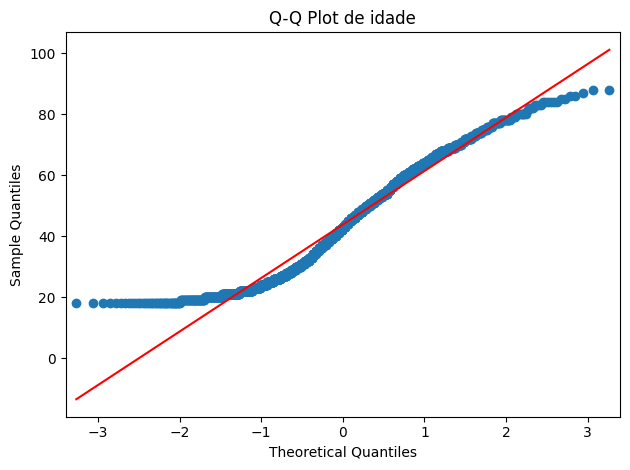

<Figure size 500x500 with 0 Axes>

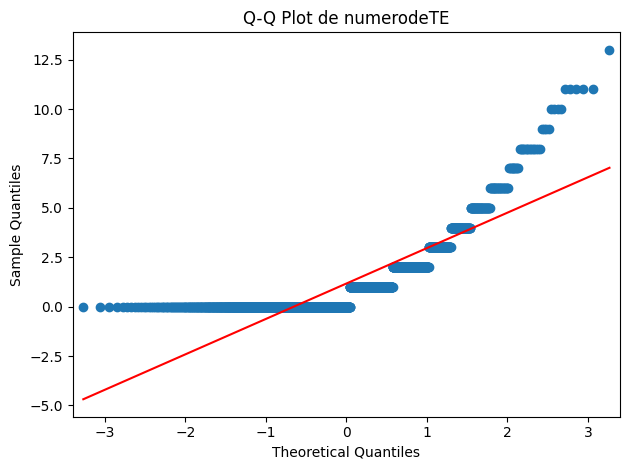

<Figure size 500x500 with 0 Axes>

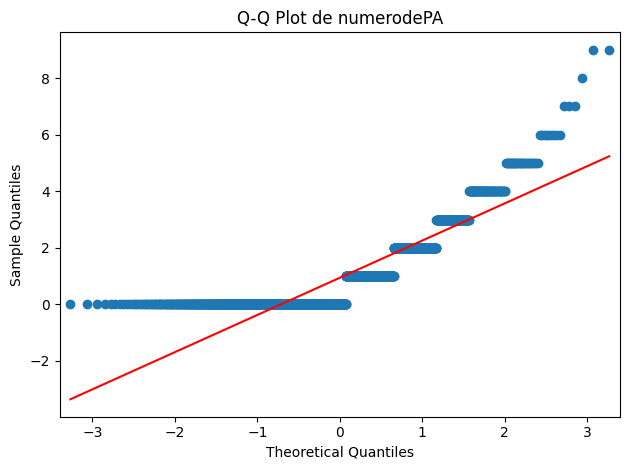

<Figure size 500x500 with 0 Axes>

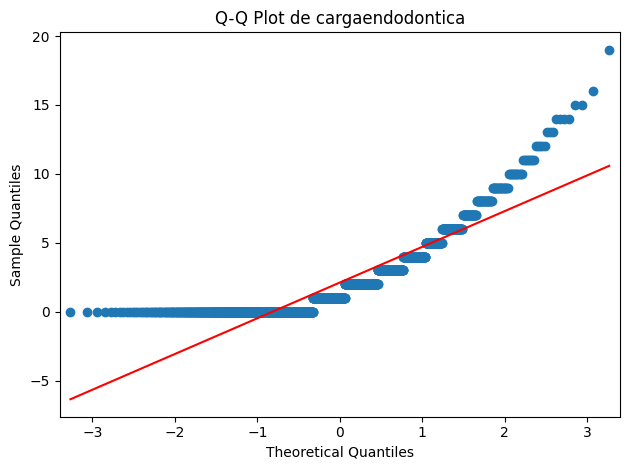

<Figure size 500x500 with 0 Axes>

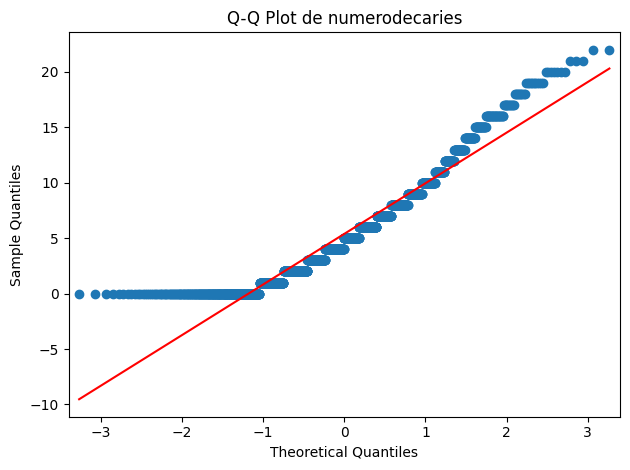

<Figure size 500x500 with 0 Axes>

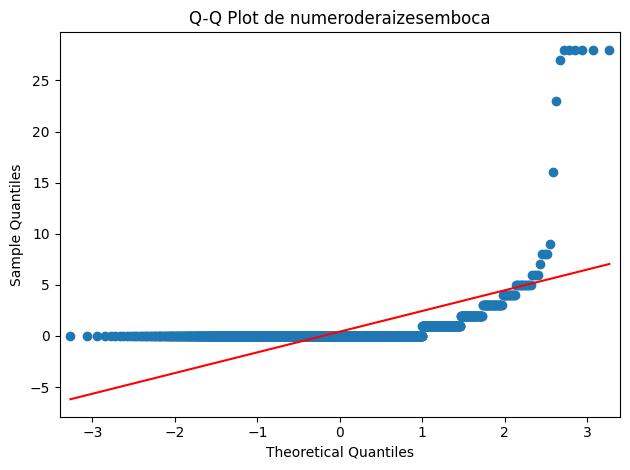

<Figure size 500x500 with 0 Axes>

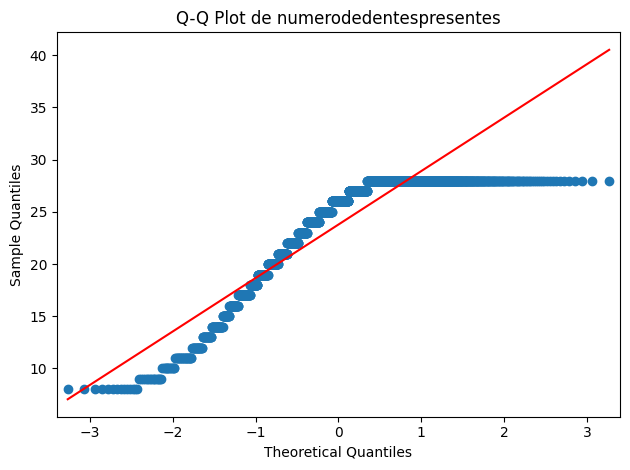

<Figure size 500x500 with 0 Axes>

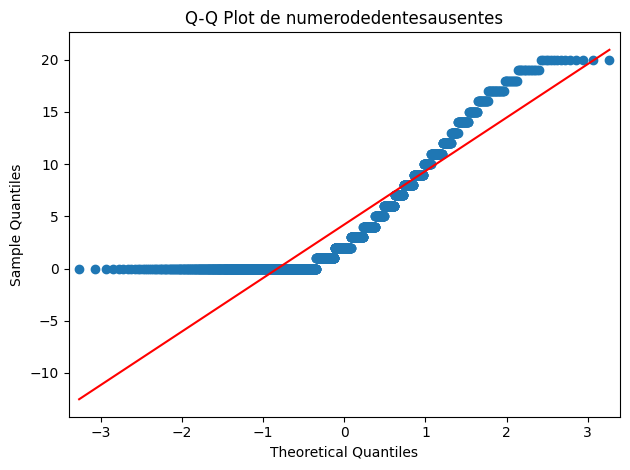

In [11]:
import statsmodels.api as sm

for var in quant_vars:
    plt.figure(figsize=(5,5))
    sm.qqplot(df[var].dropna(), line='s')
    plt.title(f"Q-Q Plot de {var}")
    plt.tight_layout()
    plt.show()


#### Correlação

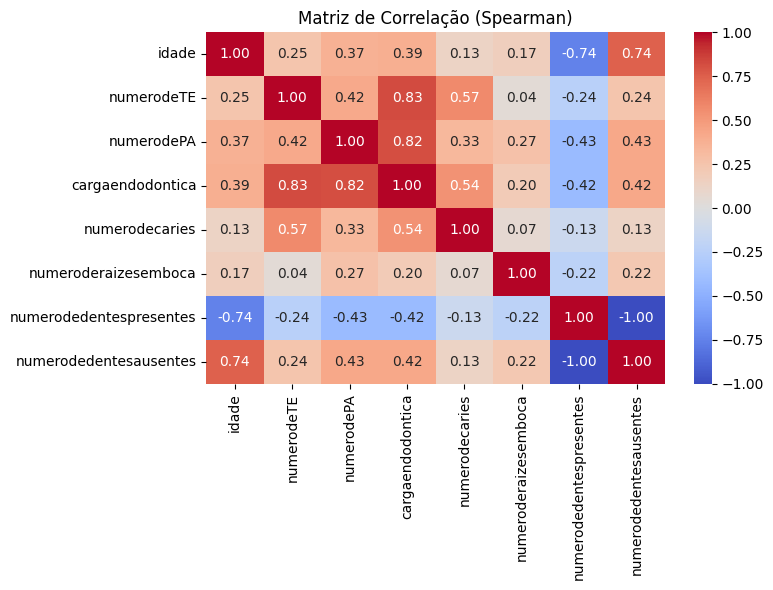

In [12]:
corr = df[quant_vars].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação (Spearman)")
plt.tight_layout()
plt.show()


### Variáveis Qualitativas Nominais Binárias



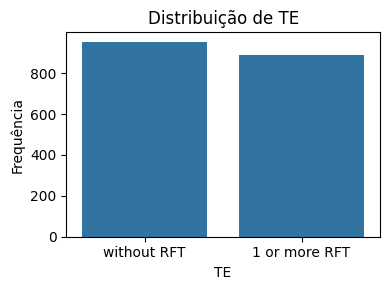

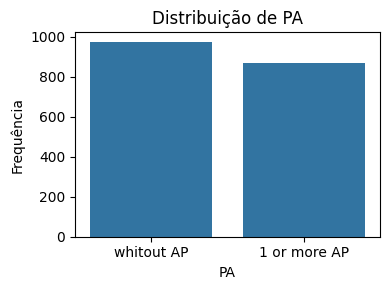

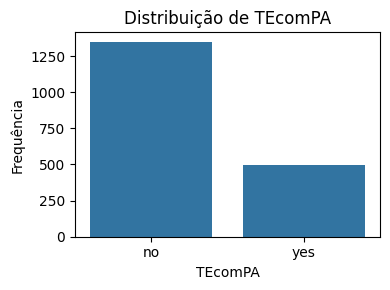

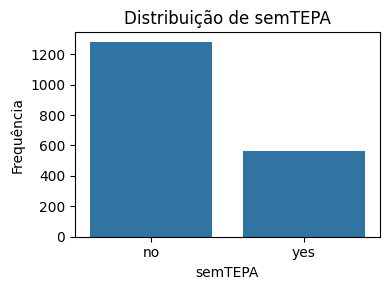

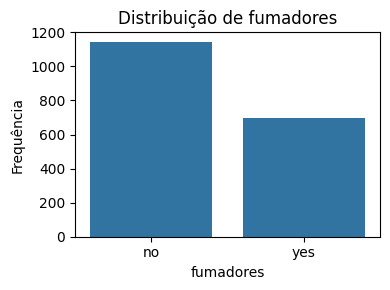

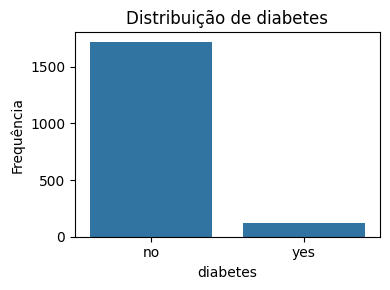

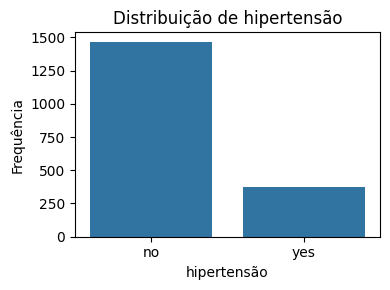

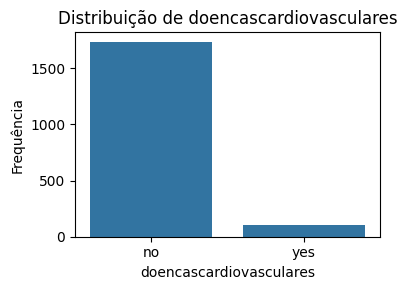

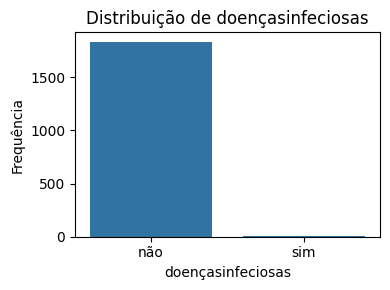

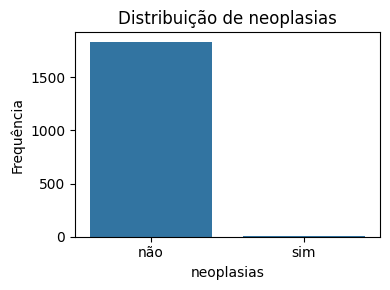

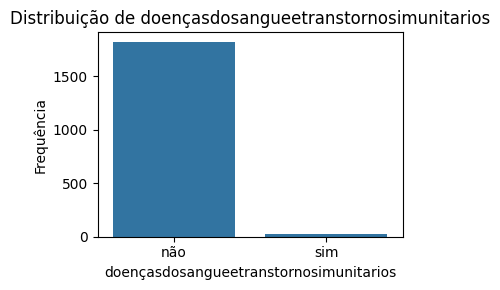

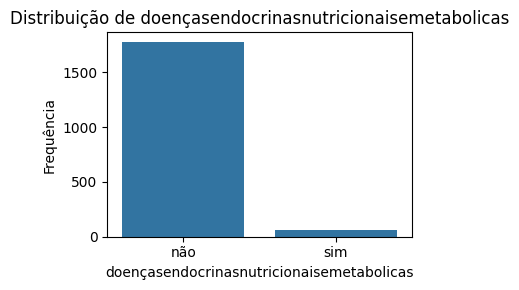

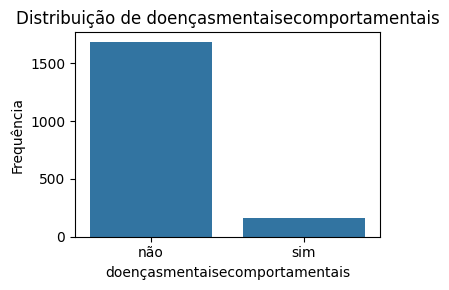

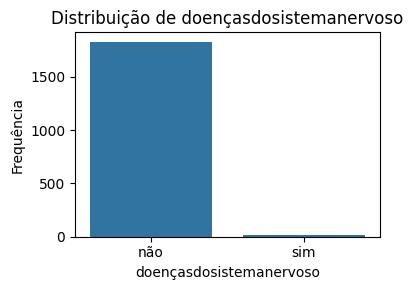

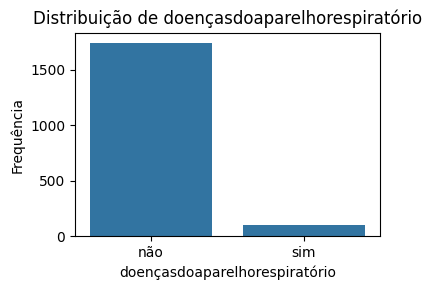

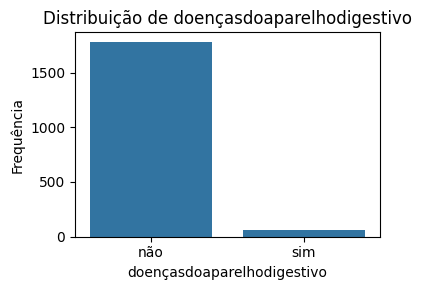

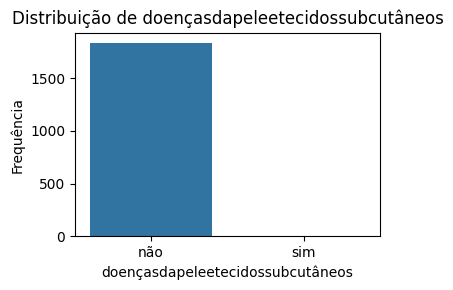

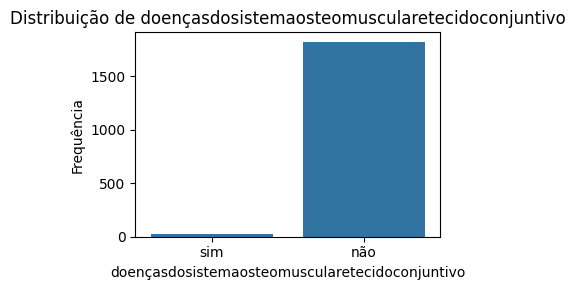

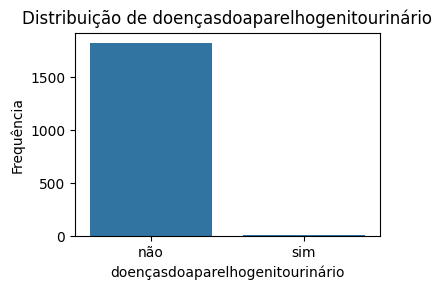

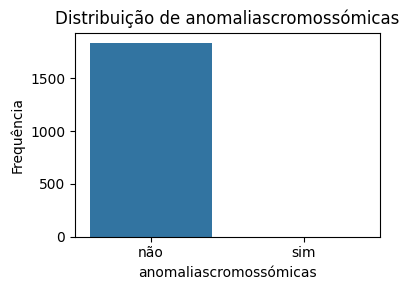

                                          Variável      Categoria     n      %
0                                               TE    without RFT   952  51.71
1                                               TE  1 or more RFT   889  48.29
2                                               PA     whitout AP   974  52.91
3                                               PA   1 or more AP   867  47.09
4                                          TEcomPA             no  1347  73.17
5                                          TEcomPA            yes   494  26.83
6                                          semTEPA             no  1280  69.53
7                                          semTEPA            yes   561  30.47
8                                        fumadores             no  1143  62.09
9                                        fumadores            yes   698  37.91
10                                        diabetes             no  1718  93.32
11                                        diabetes  

In [13]:
binary_vars = [
    "TE",
    "PA",
    "TEcomPA",
    "semTEPA",
    "fumadores",
    "diabetes",
    "hipertensão",
    "doencascardiovasculares",
    "doençasinfeciosas",
    "neoplasias",
    "doençasdosangueetranstornosimunitarios",
    "doençasendocrinasnutricionaisemetabolicas",
    "doençasmentaisecomportamentais",
    "doençasdosistemanervoso",
    "doençasdoaparelhorespiratório",
    "doençasdoaparelhodigestivo",
    "doençasdapeleetecidossubcutâneos",
    "doençasdosistemaosteomuscularetecidoconjuntivo",
    "doençasdoaparelhogenitourinário",
    "anomaliascromossómicas"
]

summary_list = []

for var in binary_vars:
    
    counts = df[var].value_counts(dropna=False)
    percentages = df[var].value_counts(normalize=True, dropna=False) * 100
    
    for category in counts.index:
        summary_list.append({
            "Variável": var,
            "Categoria": category,
            "n": counts[category],
            "%": round(percentages[category], 2)
        })
    
    # Gráfico de barras
    plt.figure(figsize=(4,3))
    sns.countplot(x=df[var])
    plt.title(f"Distribuição de {var}")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

binary_summary = pd.DataFrame(summary_list)

print(binary_summary)

### Variáveis politómicas

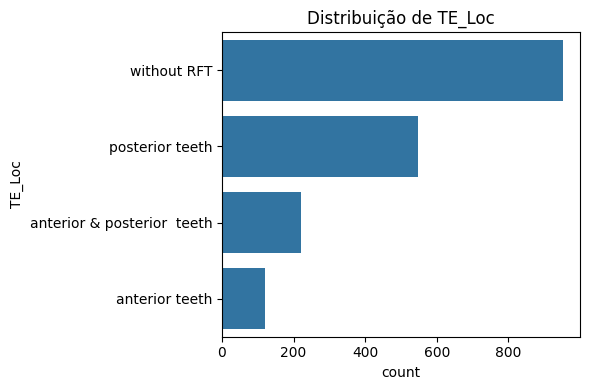

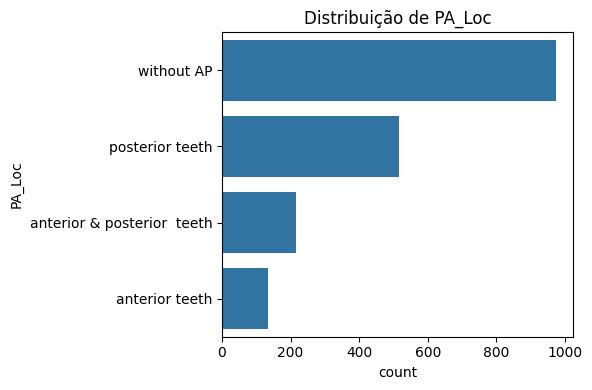

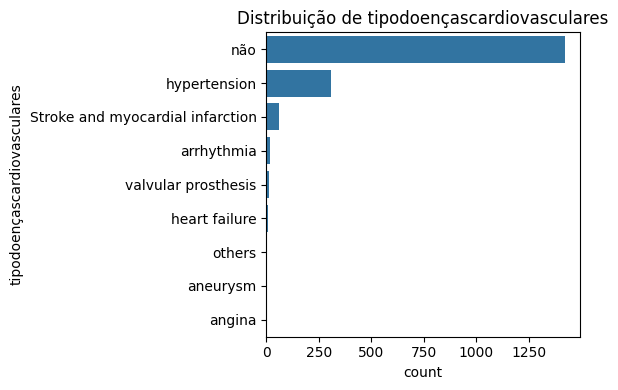

                       Variável                         Categoria     n      %
0                        TE_Loc                       without RFT   952  51.71
1                        TE_Loc                   posterior teeth   547  29.71
2                        TE_Loc       anterior & posterior  teeth   221  12.00
3                        TE_Loc                    anterior teeth   121   6.57
4                        PA_Loc                        without AP   974  52.91
5                        PA_Loc                   posterior teeth   515  27.97
6                        PA_Loc       anterior & posterior  teeth   217  11.79
7                        PA_Loc                    anterior teeth   135   7.33
8   tipodoençascardiovasculares                               não  1424  77.35
9   tipodoençascardiovasculares                      hypertension   310  16.84
10  tipodoençascardiovasculares  Stroke and myocardial infarction    61   3.31
11  tipodoençascardiovasculares                     

In [14]:
poly_vars = [
    "TE_Loc",
    "PA_Loc",
    "tipodoençascardiovasculares"
]

poly_summary = []

for var in poly_vars:
    
    counts = df[var].value_counts(dropna=False)
    percentages = df[var].value_counts(normalize=True, dropna=False) * 100
    
    for category in counts.index:
        poly_summary.append({
            "Variável": var,
            "Categoria": category,
            "n": counts[category],
            "%": round(percentages[category], 2)
        })
    
    # Gráfico
    plt.figure(figsize=(6,4))
    sns.countplot(y=df[var], order=df[var].value_counts().index)
    plt.title(f"Distribuição de {var}")
    plt.tight_layout()
    plt.show()

poly_summary_df = pd.DataFrame(poly_summary)
print(poly_summary_df)

### Variável ordinal

                 n      %
caries_cat               
0 caries       272  14.77
1 to 3 caries  475  25.80
4 to 7 caries  576  31.29
> 7 caries     518  28.14


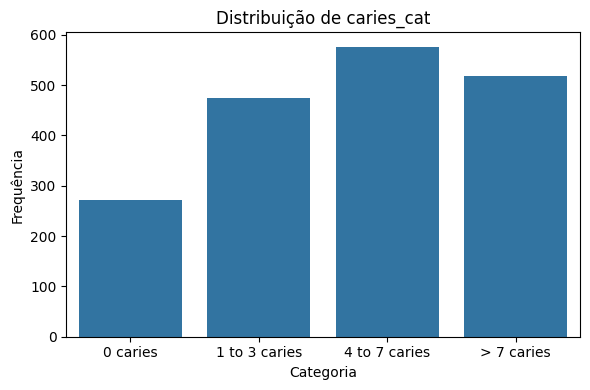

In [15]:
ordinal_var = "caries_cat"

counts = df[ordinal_var].value_counts().sort_index()
percentages = df[ordinal_var].value_counts(normalize=True).sort_index() * 100

ordinal_summary = pd.DataFrame({
    "n": counts,
    "%": round(percentages, 2)
})

print(ordinal_summary)

# Gráfico ordenado
plt.figure(figsize=(6,4))
sns.countplot(x=df[ordinal_var], order=sorted(df[ordinal_var].dropna().unique()))
plt.title("Distribuição de caries_cat")
plt.xlabel("Categoria")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# Análise Bivariada

Passar a variavel PA para binário

In [16]:
df["PA_bin"] = df["PA"].apply(lambda x: 1 if "1 or more" in x else 0)

df["PA_bin"].value_counts()

PA_bin
0    974
1    867
Name: count, dtype: int64

## Quantitativas vs PA
Teste de Mann–Whitney

In [17]:
from scipy.stats import mannwhitneyu

quant_vars = [
    "idade",
    "numerodeTE",
    "numerodePA",
    "cargaendodontica",
    "numerodecaries",
    "numeroderaizesemboca",
    "numerodedentespresentes",
    "numerodedentesausentes"
]

mw_results = []

for var in quant_vars:
    group0 = df[df["PA_bin"] == 0][var]
    group1 = df[df["PA_bin"] == 1][var]
    
    stat, p = mannwhitneyu(group0, group1)
    
    mw_results.append({
        "Variável": var,
        "U_stat": stat,
        "p_value": p
    })

mw_df = pd.DataFrame(mw_results)
mw_df.sort_values("p_value")

,Variável,U_stat,p_value
2,numerodePA,0.0,0.000000e+00
3,cargaendodontica,54496.5,2.432566e-243
1,numerodeTE,233258.0,2.375506e-72
6,numerodedentespresentes,613717.0,9.601050e-67
7,numerodedentesausentes,230741.0,9.601050e-67
0,idade,248853.0,2.211026e-52
4,numerodecaries,262328.5,3.869408e-45
5,numeroderaizesemboca,346968.5,2.365337e-25


## Binárias vs PA
Qui-quadrado

In [18]:
from scipy.stats import chi2_contingency

binary_vars = [
    "TE",
    "TEcomPA",
    "semTEPA",
    "fumadores",
    "diabetes",
    "hipertensão",
    "doencascardiovasculares",
    "doençasinfeciosas",
    "neoplasias",
    "doençasdosangueetranstornosimunitarios",
    "doençasendocrinasnutricionaisemetabolicas",
    "doençasmentaisecomportamentais",
    "doençasdosistemanervoso",
    "doençasdoaparelhorespiratório",
    "doençasdoaparelhodigestivo",
    "doençasdapeleetecidossubcutâneos",
    "doençasdosistemaosteomuscularetecidoconjuntivo",
    "doençasdoaparelhogenitourinário",
    "anomaliascromossómicas"
]

chi_results = []

for var in binary_vars:
    table = pd.crosstab(df[var], df["PA_bin"])
    chi2, p, dof, expected = chi2_contingency(table)
    
    chi_results.append({
        "Variável": var,
        "Chi2": chi2,
        "p_value": p
    })

chi_df = pd.DataFrame(chi_results)
chi_df.sort_values("p_value")

,Variável,Chi2,p_value
2,semTEPA,903.404112,1.785703e-198
1,TEcomPA,749.814001,4.403971e-165
0,TE,279.220757,1.110216e-62
3,fumadores,132.886204,9.574557e-31
5,hipertensão,115.678653,5.589034e-27
6,doencascardiovasculares,27.148506,1.884108e-07
4,diabetes,26.586899,2.519464e-07
11,doençasmentaisecomportamentais,13.561057,2.309270e-04
17,doençasdoaparelhogenitourinário,4.409292,3.574367e-02
7,doençasinfeciosas,3.142614,7.627147e-02


# Politómicas vs PA
Qui-Quadrado

In [19]:
poly_vars = [
    "TE_Loc",
    "PA_Loc",
    "tipodoençascardiovasculares"
]

chi_poly_results = []

for var in poly_vars:
    table = pd.crosstab(df[var], df["PA_bin"])
    chi2, p, dof, expected = chi2_contingency(table)
    
    chi_poly_results.append({
        "Variável": var,
        "Chi2": chi2,
        "p_value": p
    })

chi_poly_df = pd.DataFrame(chi_poly_results)
chi_poly_df.sort_values("p_value")

,Variável,Chi2,p_value
1,PA_Loc,1841.000000,0.000000e+00
0,TE_Loc,306.150574,4.640521e-66
2,tipodoençascardiovasculares,127.802065,8.073281e-24


# Ordinal vs PA
Mann-Whitney

In [20]:
# Converter caries_cat para escala ordinal numérica
mapping = {
    "0 caries": 0,
    "1 to 3 caries": 1,
    "4 to 7 caries": 2,
    "> 7 caries": 3
}

df["caries_ord"] = df["caries_cat"].map(mapping)

group0 = df[df["PA_bin"] == 0]["caries_ord"]
group1 = df[df["PA_bin"] == 1]["caries_ord"]

stat, p = mannwhitneyu(group0, group1)

print("caries_cat vs PA")
print("U_stat:", stat)
print("p_value:", p)

caries_cat vs PA
U_stat: 272277.0
p_value: 1.3067424706304835e-42


# Regressão Logistica

excluir as variaveis derivadas de PA (numerodePA, PA_Loc, semTEPA, TEcomPA)

selecionar as variaveis candidatas 

preparar os dados

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [22]:
# Selecionar variáveis

features = [
    "idade",
    "numerodeTE",
    "cargaendodontica",
    "numerodecaries",
    "numeroderaizesemboca",
    "numerodedentespresentes",
    "numerodedentesausentes",
    "TE",
    "fumadores",
    "diabetes",
    "hipertensão",
    "doencascardiovasculares",
    "doençasmentaisecomportamentais",
    "TE_Loc",
    "tipodoençascardiovasculares",
    "caries_ord"
]

X = df[features]
y = df["PA_bin"]

# Separar treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identificar tipos de variáveis

numeric_features = [
    "idade",
    "numerodeTE",
    "cargaendodontica",
    "numerodecaries",
    "numeroderaizesemboca",
    "numerodedentespresentes",
    "numerodedentesausentes",
    "caries_ord"
]

categorical_features = [
    "TE",
    "fumadores",
    "diabetes",
    "hipertensão",
    "doencascardiovasculares",
    "doençasmentaisecomportamentais",
    "TE_Loc",
    "tipodoençascardiovasculares"
]

# Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Treinar modelo

model.fit(X_train, y_train)

# Avaliar modelo

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
AUC: 1.0
Confusion Matrix:
 [[293   0]
 [  0 260]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       293
           1       1.00      1.00      1.00       260

    accuracy                           1.00       553
   macro avg       1.00      1.00      1.00       553
weighted avg       1.00      1.00      1.00       553



In [23]:
# Selecionar variáveis

features = [
    "idade",
    "cargaendodontica"
    
]

X = df[features]
y = df["PA_bin"]

# Separar treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identificar tipos de variáveis

numeric_features = [
    "cargaendodontica"
    
]

categorical_features = [
     
]

# Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Treinar modelo

model.fit(X_train, y_train)

# Avaliar modelo

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8752260397830018
AUC: 0.941782620110265
Confusion Matrix:
 [[262  31]
 [ 38 222]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88       293
           1       0.88      0.85      0.87       260

    accuracy                           0.88       553
   macro avg       0.88      0.87      0.87       553
weighted avg       0.88      0.88      0.88       553



## cargaendodontica esta a funcionar como proxy quase direto de PA

## Qual é a definição de variavel? número total de dentes com tratamento endodôntico ?




In [24]:
df["cargaendodontica"].describe()

count    1841.000000
mean        2.110266
std         2.592906
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        19.000000
Name: cargaendodontica, dtype: float64

In [25]:
pd.crosstab(df["cargaendodontica"] > 0, df["PA_bin"])

PA_bin,0,1
cargaendodontica,,
False,684,0
True,290,867


In [26]:
pd.crosstab(df["cargaendodontica"] == 0, df["PA_bin"])

PA_bin,0,1
cargaendodontica,,
False,290,867
True,684,0


Se cargaendodontica = 0 → NUNCA há PA

Se cargaendodontica > 0 → TODOS os PA estão aqui

Isto significa matematicamente:

PA = 1 ⇔ cargaendodontica > 0

## cargaendodontica é uma variável derivada que incorpora diretamente informação da variável alvo.

Não é apenas correlacionada, é determinística.

Por isso a regressão dava AUC ≈ 0.94 e antes 1.0.

Vamos remover cargaendodontica

## Regressão Logistica sem cargaendodontica,numerodePA, PA_Loc, semTEPA, TEcomPA


In [27]:


# Selecionar variáveis

features = [
    "idade",
    "numerodeTE",
    
    "numerodecaries",
    "numeroderaizesemboca",
    "numerodedentespresentes",
    "numerodedentesausentes",
    "TE",
    "fumadores",
    "diabetes",
    "hipertensão",
    "doencascardiovasculares",
    "doençasmentaisecomportamentais",
    "TE_Loc",
    "tipodoençascardiovasculares",
    "caries_ord"
]

X = df[features]
y = df["PA_bin"]

# Separar treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identificar tipos de variáveis

numeric_features = [
    "idade",
    "numerodeTE",
    
    "numerodecaries",
    "numeroderaizesemboca",
    "numerodedentespresentes",
    "numerodedentesausentes",
    "caries_ord"
]

categorical_features = [
    "TE",
    "fumadores",
    "diabetes",
    "hipertensão",
    "doencascardiovasculares",
    "doençasmentaisecomportamentais",
    "TE_Loc",
    "tipodoençascardiovasculares"
]

# Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Treinar modelo

model.fit(X_train, y_train)

# Avaliar modelo

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7450271247739603
AUC: 0.8237595169335783
Confusion Matrix:
 [[223  70]
 [ 71 189]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76       293
           1       0.73      0.73      0.73       260

    accuracy                           0.75       553
   macro avg       0.74      0.74      0.74       553
weighted avg       0.74      0.75      0.74       553



## Curva ROC

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades da classe positiva
y_prob = model.predict_proba(X_test)[:,1]

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.8237595169335783


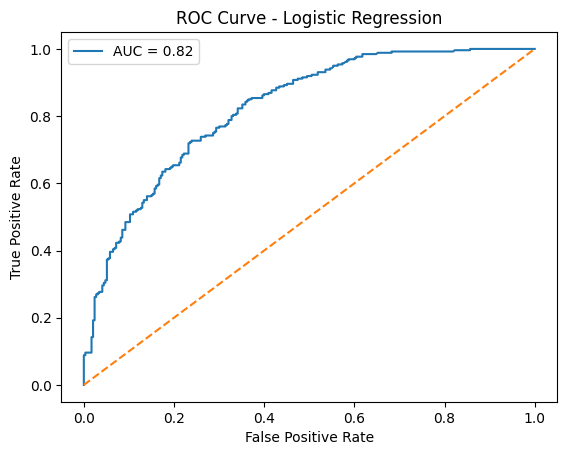

In [30]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")  # linha aleatória

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# criar pipeline
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# treinar modelo
dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [32]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Accuracy:", accuracy_dt)
print("AUC:", auc_dt)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6799276672694394
AUC: 0.6733788395904436

Confusion Matrix:
[[212  81]
 [ 96 164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.71       293
           1       0.67      0.63      0.65       260

    accuracy                           0.68       553
   macro avg       0.68      0.68      0.68       553
weighted avg       0.68      0.68      0.68       553



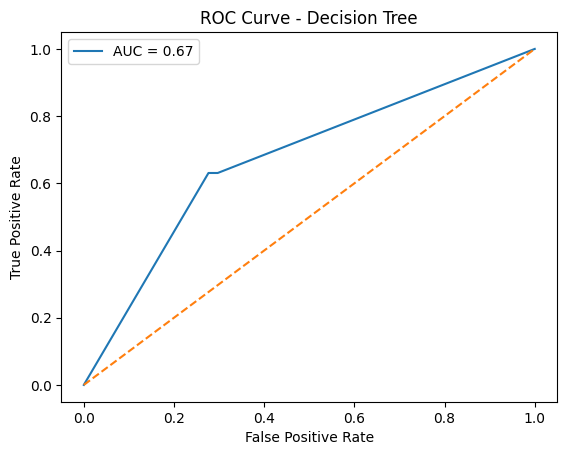

In [34]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure()

plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.2f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.savefig("curva_roc_dt.png", dpi=300, bbox_inches="tight")

plt.show()

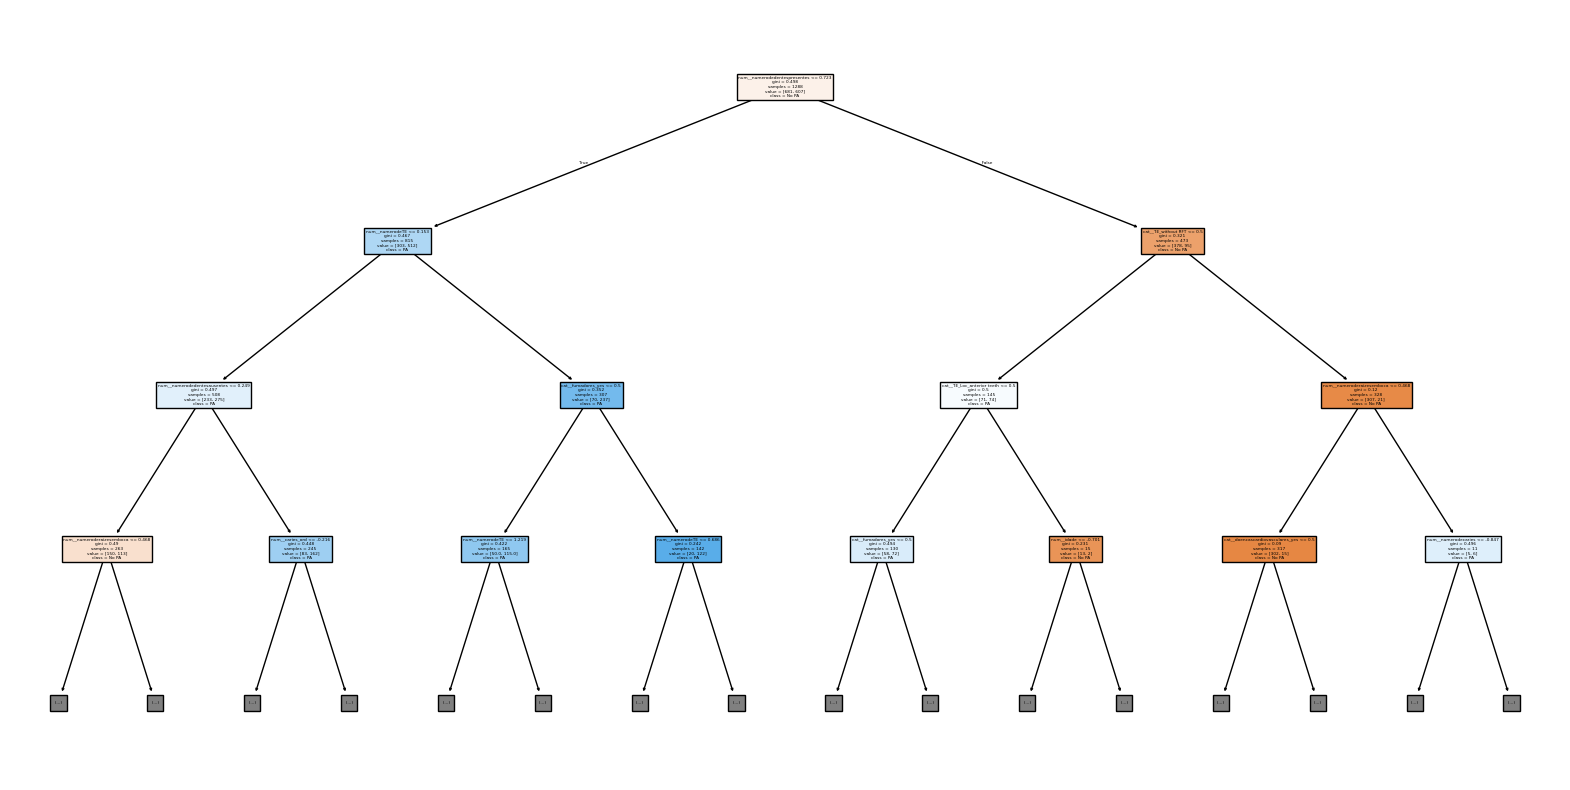

In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model.named_steps["classifier"],
    filled=True,
    feature_names=dt_model.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["No PA","PA"],
    max_depth=3
)

plt.show()

# Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [37]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy:", accuracy_rf)
print("AUC:", auc_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6998191681735986
AUC: 0.797958781832502

Confusion Matrix:
[[200  93]
 [ 73 187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.71       293
           1       0.67      0.72      0.69       260

    accuracy                           0.70       553
   macro avg       0.70      0.70      0.70       553
weighted avg       0.70      0.70      0.70       553



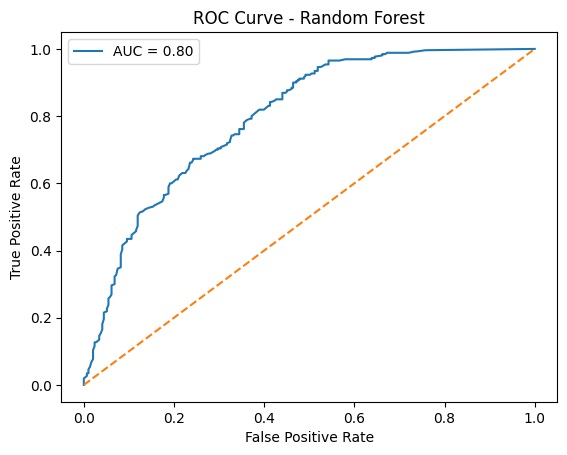

In [39]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.2f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.savefig("curva_roc_rf.png", dpi=300, bbox_inches="tight")

plt.show()

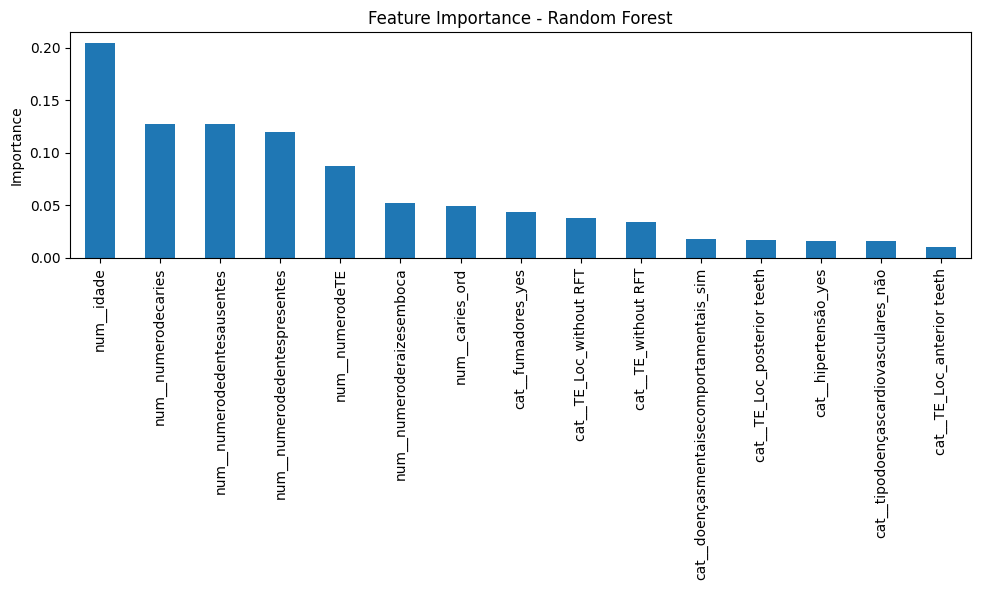

In [40]:

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind="bar")

plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")

plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=300)

plt.show()

# XG Boost

In [41]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

/Users/pedro/Desktop/Tese/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:28:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [42]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy:", accuracy_xgb)
print("AUC:", auc_xgb)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7179023508137432
AUC: 0.8069637700183776

Confusion Matrix:
[[213  80]
 [ 76 184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.73      0.73       293
           1       0.70      0.71      0.70       260

    accuracy                           0.72       553
   macro avg       0.72      0.72      0.72       553
weighted avg       0.72      0.72      0.72       553



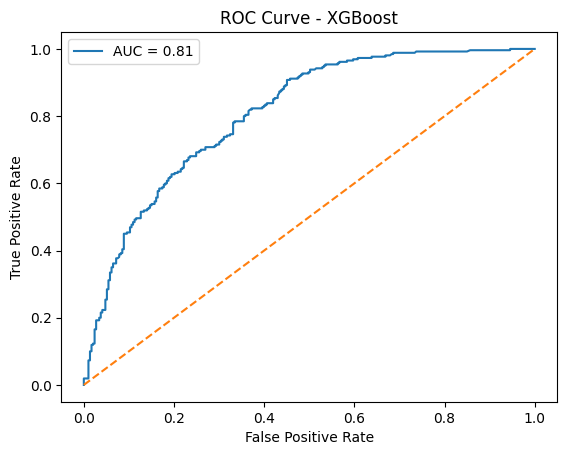

In [44]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure()

plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {auc_xgb:.2f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.legend()

plt.savefig("curva_roc_xgb.png", dpi=300, bbox_inches="tight")

plt.show()

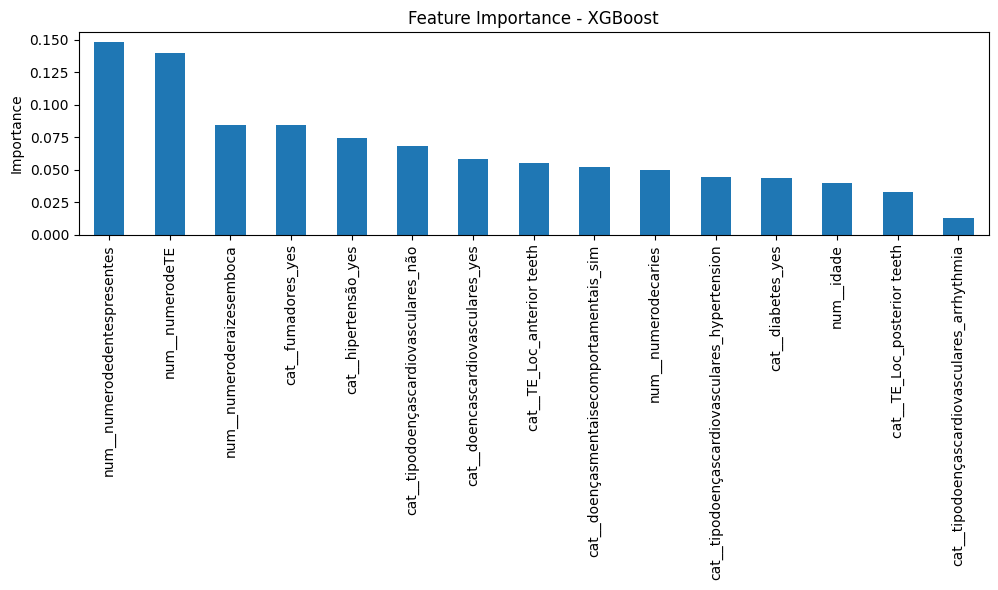

In [45]:
import pandas as pd

feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()
importances = xgb_model.named_steps["classifier"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind="bar")

plt.title("Feature Importance - XGBoost")
plt.ylabel("Importance")

plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=300)

plt.show()